# Regression Analysis

This notebook uses the previously cleaned datasets for gas and electricity usage and provides a regression analysis of the data.

Available DataFrames:
- `gas_monthly_usage`
- `electric_monthly_usage`

### Accessing the dataset

First, equivalently to how data was fetched in the eda notebook, fetch the data for gas usage and electricity usage and save the data as dataframes. Also do a visual check of imported data.

In [6]:
from pathlib import Path

import pandas as pd


def find_project_root() -> Path:
    """Walk upward until the repository root containing data/clean is found."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "data" / "clean").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root containing data/clean.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "clean"

gas_monthly_usage = pd.read_csv(
    DATA_DIR / "gas_monthly_usage.csv",
    parse_dates=["month"],
)

electric_monthly_usage = pd.read_csv(
    DATA_DIR / "electric_monthly_usage.csv",
    parse_dates=["month"],
)

print(f"Loaded gas data: {gas_monthly_usage.shape[0]:,} rows x {gas_monthly_usage.shape[1]} columns")
print(
    f"Loaded electricity data: {electric_monthly_usage.shape[0]:,} rows x {electric_monthly_usage.shape[1]} columns"
)

display(gas_monthly_usage.head())
display(electric_monthly_usage.head())

Loaded gas data: 8,412 rows x 6 columns
Loaded electricity data: 19,656 rows x 6 columns


,Property Name,Portfolio Manager ID,Property Type - Self-Selected,Gross Floor Area,month,normalized_monthly_usage
0,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-01-01,23839.31
1,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-02-01,18735.80
2,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-03-01,14082.81
3,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-04-01,11537.50
4,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-05-01,7784.48


,Property Name,Portfolio Manager ID,Property Type - Self-Selected,Gross Floor Area,month,normalized_monthly_usage
0,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-01-01,3294191.84
1,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-02-01,3188060.05
2,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-03-01,2971166.22
3,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-04-01,2861591.94
4,F.J. Horgan Water Treatment Plant,35000838,Utilities / Infrastructure,325447,2024-05-01,3142472.63


### Additional Data cleaning
- Filter the dataframes to include only pertinent columns (features and the output variable).
- Drop rows with placeholder values for the gross floor are (i.e. where the GFA = 1)


In [7]:
# Only include relavent columns for gas and electricity usage
gas_usage_for_regression = gas_monthly_usage[["Gross Floor Area", "month", "Property Type - Self-Selected", "normalized_monthly_usage"]].copy()
electricity_usage_for_regression = electric_monthly_usage[["Gross Floor Area", "month", "Property Type - Self-Selected", "normalized_monthly_usage"]].copy()

# Add month_name column to the dataset
gas_usage_for_regression['month'] = pd.to_datetime(gas_usage_for_regression['month'])
gas_usage_for_regression['month_name'] = gas_usage_for_regression['month'].dt.month_name().copy()

electricity_usage_for_regression['month'] = pd.to_datetime(electricity_usage_for_regression['month'])
electricity_usage_for_regression['month_name'] = electricity_usage_for_regression['month'].dt.month_name().copy()

# Drop NA values
gas_usage_for_regression = gas_usage_for_regression.dropna(
    subset=["Gross Floor Area", "normalized_monthly_usage"]
)

electricity_usage_for_regression = electricity_usage_for_regression.dropna(
    subset=["Gross Floor Area", "normalized_monthly_usage"]
)

# Remove placeholder Gross Floor Area = 1
gas_usage_for_regression = gas_usage_for_regression[
    gas_usage_for_regression["Gross Floor Area"] != 1
]

electricity_usage_for_regression = electricity_usage_for_regression[
    electricity_usage_for_regression["Gross Floor Area"] != 1
]

#display(electricity_usage_for_regression.head())
#display(gas_usage_for_regression.head())

print(len(gas_usage_for_regression["normalized_monthly_usage"]))
print(len(gas_usage_for_regression["Gross Floor Area"]))

# gas_usage_for_regression = pd.get_dummies(gas_usage_for_regression, columns=['month_name'])

8052
8052


### Simple regression analysis only using GFA and monthly usage

First we will conduct a simple regression analysis, utilizing the GFA (feature) and monthly usage (output) variables alone.  Based on the scatterplot from the EDA notebook, we expect this analysis to be "unfulfilling".

##### Gas usage

In [8]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

x = gas_usage_for_regression["Gross Floor Area"].to_numpy().reshape(-1, 1)
y = gas_usage_for_regression["normalized_monthly_usage"].to_numpy().reshape(-1, 1)

#Split the dataset into training and test data, test_size will be 15% of cleaned data, and select a random state to reproduce results.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15, random_state=28)

#Run the regression using test data
simple_gas_regression = linear_model.LinearRegression()
simple_gas_regression.fit(x_train, y_train)

#predict y values using test values for x
y_pred = simple_gas_regression.predict(x_test)

#generate MSE and r2_score
mse = mean_squared_error(y_test, y_pred)
r2_score = r2_score(y_test, y_pred)

print("Cofficients (only 1):", simple_gas_regression.coef_[0])
print("Intercept:", simple_gas_regression.intercept_)

print("MSE:", mse)
print("R2 score:", r2_score)


Cofficients (only 1): [0.16336148]
Intercept: [1140.20987134]
MSE: 961501300.4589884
R2 score: 0.12603625410689945


Results are lackluster but unsurprising, MSE: 961501300.4589884 (very large) while R2 score: 0.12603625410689945 (quite small), indicating the model was not a very good fit. A simple visualization will solidify this fact.

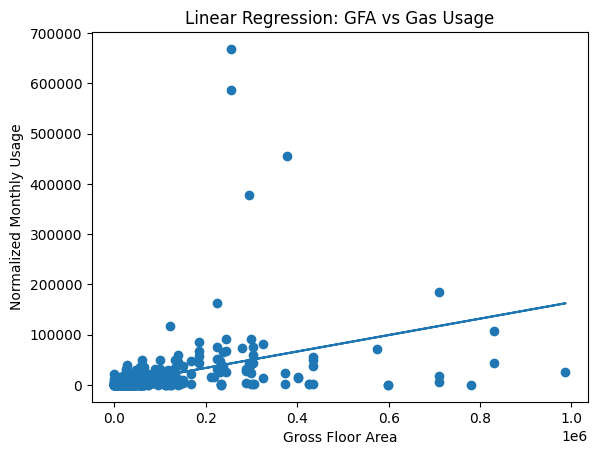

In [9]:
import matplotlib.pyplot as plt

plt.scatter(x_test, y_test)
plt.plot(x_test, y_pred)

plt.xlabel("Gross Floor Area")
plt.ylabel("Normalized Monthly Usage")
plt.title("Linear Regression: GFA vs Gas Usage")

plt.show()

The presence of outliers may be skewing the model, creating a positive slope. The outliers here for simplicity's sake can be any point considered to have a normalized monthly usage for gas above 300,000 cm (cubic metres) or a gross floor area of ~0.6 * 10 ^ 6 square feet. However, since outliers for gross floor area will likely be the same outliers in the analysis for electricity usage, we won't investiage them at this point. We will look into outliers based on gas usage alone for now.

In [10]:
gas_usage_outliers = gas_usage_for_regression[gas_usage_for_regression['normalized_monthly_usage'] > 300000]
gas_usage_outliers

,Gross Floor Area,month,Property Type - Self-Selected,normalized_monthly_usage,month_name
876,378438,2024-01-01,Utilities / Infrastructure,761346.23,January
877,378438,2024-02-01,Utilities / Infrastructure,640730.41,February
878,378438,2024-03-01,Utilities / Infrastructure,540328.37,March
879,378438,2024-04-01,Utilities / Infrastructure,454734.55,April
880,378438,2024-05-01,Utilities / Infrastructure,368323.96,May
881,378438,2024-06-01,Utilities / Infrastructure,402606.58,June
882,378438,2024-07-01,Utilities / Infrastructure,380321.81,July
883,378438,2024-08-01,Utilities / Infrastructure,403499.93,August
884,378438,2024-09-01,Utilities / Infrastructure,397485.55,September
885,378438,2024-10-01,Utilities / Infrastructure,478849.09,October


Outliers are from buildings involved with utilities/infrastructure, public services, and transportation. 1 or 2 outliers for each category based on building type assuming the GFAs are unique per property in this reduced dataset of outliers.

In [21]:
gas_usage_outlier_properties = gas_monthly_usage[gas_monthly_usage["normalized_monthly_usage"] > 300_000].groupby('Property Name')['Gross Floor Area'].min()
gas_usage_outlier_properties

Property Name
Highland Creek Treatment Plant      255395
Hillcrest, Gunn, Bathurst Garage    295000
Main Treatment Plant                378438
Malvern Garage & Shop               574125
Mt. Dennis Bus Garage               710493
Toronto-York Spadina Subway              1
Name: Gross Floor Area, dtype: int64

These properties have a very high gas usage for at least one month (>300,000 cm). We do not count the property of Toronto-York Spadina Subway as it has a placeholder value for GFA. It makes sense for properties of this type to have high gas usage for at least one month given their services.

##### Electricity Usage

In [23]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

x = electricity_usage_for_regression["Gross Floor Area"].to_numpy().reshape(-1, 1)
y = electricity_usage_for_regression["normalized_monthly_usage"].to_numpy().reshape(-1, 1)

#Split the dataset into training and test data, test_size will be 15% of cleaned data, and select a random state to reproduce results.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15, random_state=17)

#Run the regression using test data
simple_electricity_regression = linear_model.LinearRegression()
simple_electricity_regression.fit(x_train, y_train)

#predict y values using test values for x
y_pred = simple_electricity_regression.predict(x_test)

#generate MSE and r2_score
mse = mean_squared_error(y_test, y_pred)
r2_score = r2_score(y_test, y_pred)

print("Cofficients (only 1):", simple_electricity_regression.coef_[0])
print("Intercept:", simple_electricity_regression.intercept_)

print("MSE:", mse)
print("R2 score:", r2_score)


Cofficients (only 1): [2.24610573]
Intercept: [9430.45059689]
MSE: 186145086325.78668
R2 score: 0.13196768280718318


As was the case with the gas usage, the regression for electricity usage shows no obvious linear trend (low r2 score and high MSE). We will use a chart to visualize this as before.

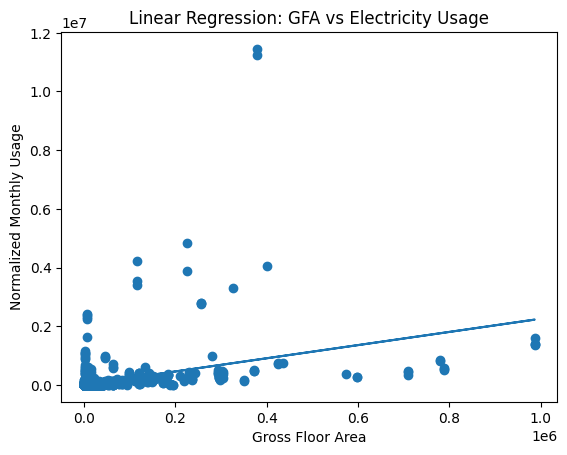

In [26]:
import matplotlib.pyplot as plt

plt.scatter(x_test, y_test)
plt.plot(x_test, y_pred)

plt.xlabel("Gross Floor Area")
plt.ylabel("Normalized Monthly Usage")
plt.title("Linear Regression: GFA vs Electricity Usage")

plt.show()

Let's once again check for outliers, this time using a monthly usage of 0.3 * 10 ^ 7 KwH as the baseline.

In [28]:
electric_usage_outlier_properties = electric_monthly_usage[electric_monthly_usage["normalized_monthly_usage"] > 3_000_000].groupby('Property Name')['Gross Floor Area'].min()
electric_usage_outlier_properties

Property Name
F.J. Horgan Water Treatment Plant    325447
Highland Creek Treatment Plant       255395
Humber Treatment Plant               224869
Main Treatment Plant                 378438
R.C. Harris Water Treatment Plant    115368
R.L. Clark Water Treatment Plant     401612
Street Lighting Etobicoke                 1
Street Lighting North York                1
Street Lighting Scarborough               1
Street Lighting Toronto                   1
Wilson Substation                         1
Name: Gross Floor Area, dtype: int64

Filtering out the outliers with placeholder GFA values, electricity usage for at least one month is high exclusively for treatment plants which high in this case is > 3 million kwH. Also note that the Highland Creek Treatment plant also had a month with very high gas usage according to the outliers found in the previous analysis.

##### Conclusion from Simple Regression Analysis for Energy Usage
In both cases, there was not a strong linear trend between GFA and energy usage. However, it is interesting to note the outliers, one of which appears high in both electricity and gas usage for at least one month (Highland Creek Treatment Plant ). Further analysis could be done excluding the outliers, however this could muddle the analysis, though intuitively it may show a futher lack of corellation between gross floor area and energy usage, which could also be insightful. Further analysis in this regard may be conducted in the future.

### Regression analysis using GFA, property type and monthly usage

We will now take a step further and conduct an analysis adding the property type as a categorical variable. Reuse the gas_usage_for_regression and electric_usage_for_regression variables.

In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

# Features and target
x = gas_usage_for_regression[['Gross Floor Area', 'Property Type - Self-Selected']]
y = gas_usage_for_regression['normalized_monthly_usage']  

# Encode categorical variable
x_encoded = pd.get_dummies(
    x,
    columns=["Property Type - Self-Selected"],
    drop_first=True
)

# Split encoded data
x_train, x_test, y_train, y_test = train_test_split(
    x_encoded, y, test_size=0.15, random_state=28
)

# Train model
multi_gas_regression = linear_model.LinearRegression()
multi_gas_regression.fit(x_train, y_train)

# Predict
y_pred = multi_gas_regression.predict(x_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Coefficients:")
for feature, coef in zip(x_encoded.columns, multi_gas_regression.coef_):
    print(f"{feature}: {coef}")

print("Intercept:", multi_gas_regression.intercept_)
print("MSE:", mse)
print("R2 score:", r2)

Coefficients:
Gross Floor Area: 0.09966193178405396
Property Type - Self-Selected_Education & Social Services: 3409.9790570077603
Property Type - Self-Selected_Other-Public Services: 4607.45712720375
Property Type - Self-Selected_Public Safety: 3376.0625415535633
Property Type - Self-Selected_Recreation & Community: 4726.656986234435
Property Type - Self-Selected_Transportation: 36671.19496370643
Property Type - Self-Selected_Utilities / Infrastructure: 154866.1088636451
Intercept: -2743.9002818584913
MSE: 788482181.6883913
R2 score: 0.2833032667252813


In this case, there is a better R2 score compared to in the case with simple regression, however the MSE is still high, and interestingly enough, there is a negative intercept. Considering the values for the encoded binary values, the intercept will not logically affect most types of properties since all the binary values are greater than the absolute value of the intercept. Let's once again visuallize the data.